# **CNNs PROFUNDAS E MODELOS PRÉ-TREINADOS**

Neste material, descreverei três redes neurais convolucionais (CNNs): a VGGNet, a GoogLeNet e a ResNet. A VGGNet tem 16 camadas, a GoogLeNet tem 22 e a ResNet-152 possui 152 camadas, mas, na prática, a maioria das pessoas usam a ResNet-50, com 50 camadas.

## **VGGNet**

A **VGGNet** foi proposta pelo Visual Geometry Group (VGG) da Universidade de Oxford. Um objetivo principal do artigo que descreveu a arquitetura foi estudar o efeito que a profundidade da rede tem na acurácia para CNNs. Para isso, eles criaram uma arquitetura na qual a profundidade da rede pode ser ajustada sem ter que ajustar outros parâmetros, como o tamanho do *kernel* e o *stride*. Eles usaram um tamanho de *kernel* fixo de 3x3 em todas as camadas convolucionais e um *stride* de 1. Usando o *stride* de 1, e assumindo que o *padding* apropriado foi usado, a largura e a altura das camadas convolucionais serão iguais. Isso possibilita tornar uma **VGGNet** arbitrariamente profunda sem sofrer com o problema de a largura e a altura das camadas mais profundas na rede se tornarem muito pequenas.

Como um dos objetivos é diminuir a altura e a largura para as outras camadas mais profundas, para que os neurônios identifique *features* de tamanho maior. A **VGGNet** resolve isso usando camadas de *max pooling* entre grupos de camadas convolucionais. Assim, um bloco de construção típico em uma **VGGNet** é um grupo de camadas convolucionais do mesmo tamanho, seguido por uma camada de *max pooling*.

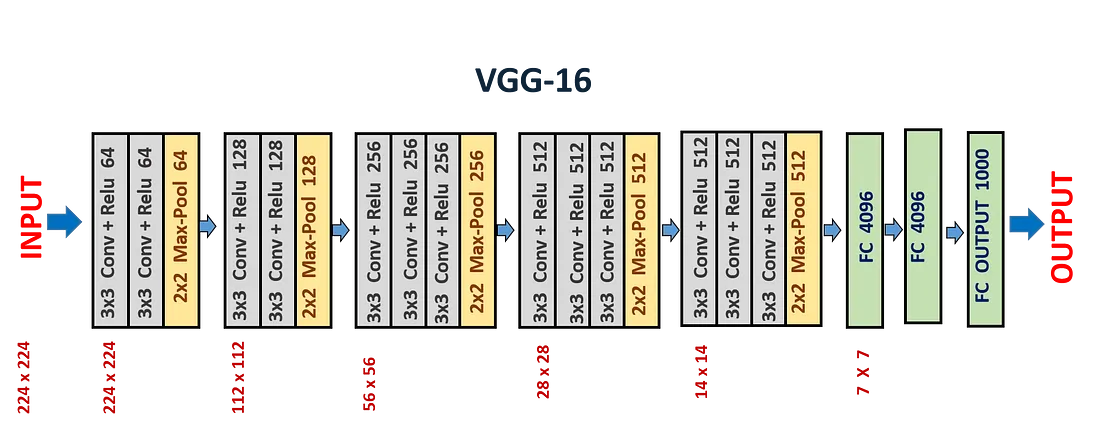 *Arquitetura da VGGNet com 16 camadas. Note que as camadas de convoluções sempre com mesma dimensão até que ocorra o max pool.*

Observando a imagem acima, nota-se a **VGGNet* começa com camadas convolucionais com 64 canais. Para cada camada de *max pooling*, a largura e a altura da próxima camada são reduzidas pela metade, e a camada convolucional subsequente dobra o número de canais. O número de canais é limitado a 512, após o qual a largura e a altura ainda são reduzidas pela metade para a próxima camada após o *pooling*, mas o número de canais é mantido constante. Os neurônios em todas as camadas convolucionais usam *ReLU* como função de ativação. 

Alguns resultados importantes do estudo da **VGGNet** foram que a acurácia da previsão aumentou com a profundidade do modelo até 16 camadas, mas depois se estabilizou em aproximadamente o mesmo nível para 19 camadas. *As camadas de pooling não foram incluídas nessas contagens porque não contêm pesos que podem ser treinados.*

A melhor configuração de classificação da **VGGNet** submetida ao desafio *ImageNet* 2014 resultou em uma taxa de erro top-5 de 7,32%. Isso pode ser comparado aos 15,3% da AlexNet. Essa taxa de erro top-5 é definida como a porcentagem de imagens de teste onde a categoria correta não está entre as cinco categorias que a rede prevê como as mais prováveis.

## **GoogLeNet**

A **GoogLeNet** é um bom exemplo de uma arquitetura de rede chamada *Inception*. Quando se vê ela pela primeira vez, ela parece muito mais complexa e irregular do que a *AlexNet e a VGGNet*, porque ela usa um bloco de construção chamado *módulo Inception*, que por si só é uma pequena rede. Este é um exemplo de uma arquitetura de **rede-dentro-de-rede (network-in-network)**, na qual uma pequena rede é usada como bloco de construção dentro de outra rede.

Os idealizadores dessa arquitetura rede-dentro-de-rede estavam estudando uma arquitetura disso para *CNN*, onde cada neurônio de uma camada convolucional seria substituído por uma pequena rede de múltiplos níveis, que servia para o mesmo papel do neurônio substituído. Assim como em uma camada convolucional tradicional, esta pequena rede de múltiplos níveis compartilharia pesos por toda a camada convolucional. O efeito é uma camada convolucional com a capacidade de classificar features que não são linearmente separáveis, o que não é possível para uma única camada convolucional tradicional. 

No entanto, o módulo **Inception** usado pela **GoogLeNet** tem um propósito diferente. Ele constrói uma camada convolucional que pode trabalhar, ao mesmo tempo, com **múltiplos tamanhos de campo receptivo**. Intuitivamente, isso pode ser útil porque raramente uma instância de um objeto específico (por exemplo, um gato) tem sempre o mesmo tamanho em todas as imagens.

O módulo **Inception** aborda a flexibilidade do tamanho do campo receptivo tendo múltiplas camadas convolucionais com diferentes tamanhos de *kernel* trabalhando lado a lado, cada uma produzindo um número de canais de saída. Contanto que a largura e a altura dos canais de saída sejam as mesmas, esses canais podem simplesmente ser concatenados para parecerem que vêm de uma única camada convolucional. Por exemplo, podemos ter 32 canais resultantes de uma camada convolucional com um *kernel* de 3x3 e 32 canais resultantes de uma camada com um *kernel* de 5x5, e no geral, o módulo *Inception* produziria 64 canais.

Como o custo computacional está diretamente ligado ao tamanho do *kernel* e ao número de canais na camada precedente, pois é isso que determina o número de pesos de uma camada convolucional (e o número de pesos influencia na quantidade de cálculos que o modelo irá fazer), o módulo **Inception** busca diminuir esse custo. Para isso, ele faz uso de convoluções de 1x1 antes de convoluções de 3x3 e 5x5, o que resulta em menos canais de entrada para esses *kernels* convolucionais. Da mesma forma, para evitar muitos canais de saída, uma convolução de 1x1 é aplicada à saída da operação de *max pooling*. Com essas convoluções de 1x1, temos controle total sobre o número de canais de entrada para os *kernels* de 3x3 e 5x5, bem como o número total de saídas do módulo **Inception** e, consequentemente, o número de pesos que precisam ser treinados.

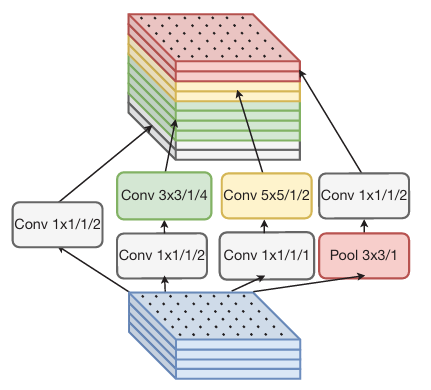 *Exemplo do módulo **Inception** do GoogLeNet*

*Nota-se que o stride escolhido é 1, pois o objetivo é ter as saídas com mesma altura e largura da entrada, para depois combiná-las. O uso do max pooling sem diminuir as dimensões da saída parece estranho, porém a justificativa usada foi simplesmente porque ele demonstrou ser útil em redes de ponta.*

Para permitir o treinamento de redes mais profundas, eles adicionaram **classificadores auxiliares** em diferentes pontos da rede. Um classificador auxiliar é similar ao que tipicamente colocaríamos no topo da rede, ou seja, uma camada totalmente conectada e uma camada *softmax* que calcula a probabilidade para as diferentes classes que estamos tentando prever. O objetivo desses classificadores auxiliares é poder injetar gradientes nesses pontos intermediários durante o treinamento e, assim, garantir que gradientes fortes se propaguem de volta para as primeiras camadas. Os classificadores auxiliares também incentivam as camadas iniciais da rede a serem treinadas para se comportarem de maneira muito semelhante a como se comportariam em uma rede mais rasa.

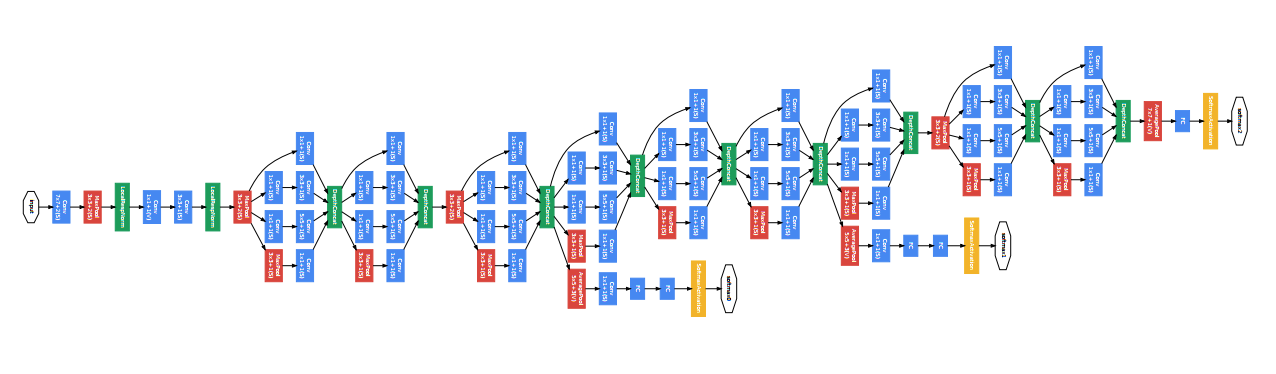 *Arquitetura da GoogLeNet*

No geral, a **GoogLeNet** demonstrou que é possível fazer uso de arquiteturas mais elaboradas para construir redes profundas de alto desempenho que têm um número relativamente pequeno de pesos. A rede de 22 camadas que foi submetida ao desafio de classificação *ImageNet* 2014 alcançou um erro top-5 de 6,67%, o que foi ligeiramente melhor que a VGGNet.

## **ResNet**

**Redes Residuais (ResNets)** foram introduzidas para resolver a observação de que redes muito profundas são difíceis de treinar. Comentei anteriormente que um obstáculo para o treinamento de redes profundas é o problema do **desaparecimento do gradiente**. No entanto, acontece que redes profundas ainda têm problemas para aprender, mesmo após resolver o problema do desaparecimento do gradiente, inicializando os pesos adequadamente, aplicando normalização em lote e usando neurônios de unidade linear retificada (ReLU) dentro da rede. 

Pesquisadore observaram que, ao aumentar a profundidade da rede de 18 para 34 camadas, o erro de treinamento aumentou, embora parecessem ter gradientes saudáveis por toda a rede durante o processo de treinamento. Se apenas o erro de teste aumentasse, isso seria uma indicação de sobreajuste (*overfitting*). Um erro de treinamento aumentado indica que este modelo mais complexo simplesmente não conseguiu aprender o que deveria ser capaz de aprender, dada sua capacidade estritamente maior que a do modelo de 18 camadas. As **ResNets** resolvem este problema usando um mecanismo conhecido como conexão de salto (*skip connection*).

É claro que construir uma rede muito profunda onde muitas das camadas não alteram a saída seria um desperdício, mas o raciocínio aqui é que a melhor solução para as camadas posteriores pode ser próxima à função identidade, **porque apenas pequenas variações são necessárias para melhorar a acurácia**. Assim, ao facilitar que as camadas aprendam algo próximo à função identidade, o algoritmo de aprendizado iniciará sua busca por uma solução em um espaço que provavelmente contém uma boa solução.

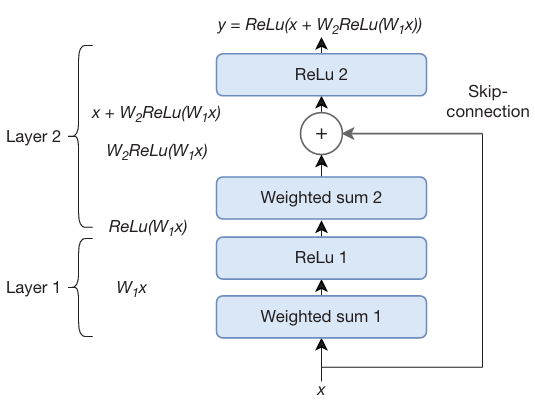 *Exemplo de um bloco de construção que pode ser usado em uma ResNet. Esse bloco contém duas camadas empilhadas com uma conexão de salto adicional que "contorna" a maior parte das duas camadas. Como se pode ver na figura, a entrada (x) para a primeira camada é somada à soma ponderada produzida pela segunda camada, antes que essa soma passe pela função de ativação na segunda camada.*

Assumindo que as duas camadas sejam *fully connected* com o mesmo número de saídas e entradas, o bloco de construção acima pode ser representado da seguinte forma usando matrizes e vetores:

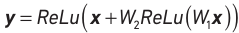 *O produto mais interno (W1x) representa a soma ponderada da primeira camada, após isso, o vetor de saída da função de ativação ReLU é multiplicado pela matriz W2 para o cálculo da soma ponderada da segunda camada.*

Com este arranjo, é mais fácil que o algoritmo de aprendizado "empurre" os pesos para perto de 0. Isso se a função identidade for o comportamento desejado. A expressão, após isso, ficaria:



**ARQUITETURA BÁSICA DE UMA REDE RESIDUAL (RESNET)**

A estrutura básica dessa rede é inspirada na **VGGNet**, pois consiste em grupos de camadas convolucionais empilhadas, construídas a partir de *kernels* de 3x3 usando um *stride* de 1 e com o mesmo número de canais de saída e de entrada. Como a **VGGNet**, uma **ResNet** introduz periodicamente camadas que reduzem pela metade a largura e a altura, enquanto dobram o número de canais de saída. No entanto, enquanto a **VGGNet** reduzia as dimensões usando *max pooling*, a **ResNet** usa um *stride* de 2 nas camadas convolucionais onde a redução de dimensionalidade é desejada, e assim o *max pooling* não é necessário. Outra diferença é que a **ResNet** emprega normalização em lote após cada camada convolucional. Ambas as diferenças são independentes das conexões de salto que representam o principal diferencial de uma **ResNet**.

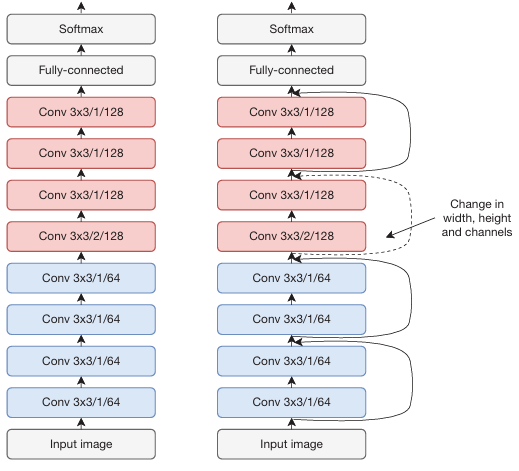 *Imagem que mostra uma rede sem conexões de salto (à esquerda) e uma rede com conexões de salto (à esquerda)*

Como visto na imagem acima, existem dois tipos de conexões de salto. A primeira (linha sólida) conecta uma entrada de um determinado tamanho a uma saída do mesmo tamanho, e a segunda (linha tracejada) conecta uma entrada de um determinado tamanho a uma saída de um tamanho diferente. Ambas são aplicadas a camadas convolucionais que têm uma estrutura 3D (largura x altura x canais). A fórmula a seguir mostra como a conexão de salto é definida para duas camadas convolucionais quando as entradas e saídas são do mesmo tamanho: 

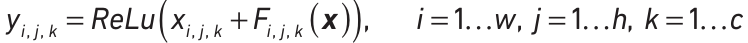 *w, h e c representam a largura, a altura e o número de canais.*

*Nota-se que simplesmente aplicamos uma conexão de salto de uma dada coordenada no tensor de entrada para a coordenada correspondente no tensor de saída.*

Mas como fica essa fórmula quando o tensor de saída tem uma dimensionalidade diferente do de entrada? Em particular, no caso de uma **ResNet**, a largura e a altura do tensor de saída são metade das do tensor de entrada, e o número de canais é duplicado. Aqui está uma solução simples: 

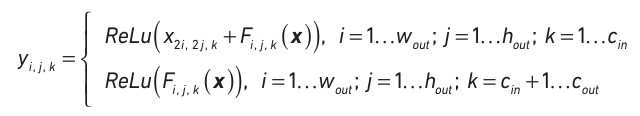 *w, h e c representam a largura, a altura e o número de canais, com a adição de um subscrito detalhando se uma variável se refere ao tensor de entrada ou de saída para o bloco.*

Como o número de canais de saída é duplicado, simplesmente temos conexões de salto apenas para a primeira metade dos canais de saída. Na fórmula, isso é alcançado fazendo com que a primeira linha (com conexões de salto) se aplique à primeira metade dos canais de saída (1 a Cin), e a segunda linha (sem conexões de salto) se aplique à metade restante dos canais de saída (Cin + 1 a Cout). Da mesma forma, como a largura e a altura são cortadas pela metade, fazemos conexões de salto apenas de cada segundo elemento nas dimensões de largura e altura no tensor de entrada (alcançado usando os subscritos 2i e 2j na primeira linha da fórmula).

Acontece que uma solução melhor do que ter conexões de salto para apenas metade dos canais de saída é usar uma convolução de 1x1 na conexão de salto para expandir o número de canais da própria conexão de salto.

Além disso, para tornar prático o uso de redes profundas com ainda mais canais, podemos usar convoluções de 1x1 para reduzir temporariamente o número de canais para diminuir o número de pesos necessários na camada convolucional de 3x3 e, em seguida, usar outra camada de convoluções de 1x1 para aumentar o número de canais novamente.

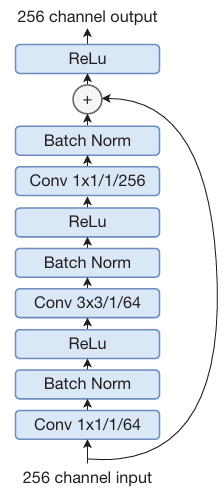 *Utilização dessa ideia comentada acima em uma ResNet. Primeiro diminui-se a quantidade de canais e no final aumenta.*

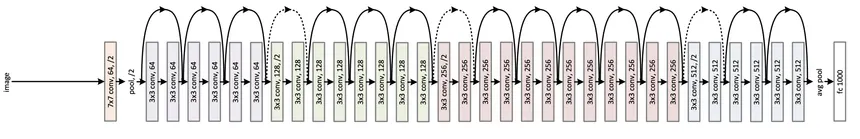 *Arquitetura da ResNet-50*

Usando uma combinação de algumas **ResNets** diferentes, os pesquisadores relataram um erro top-5 de 3,57% no desafio de classificação *ImageNet* em 2015.

## **HANDS-ON: IMPLEMENTAÇÃO DE UM RESNET PRÉ-TREINADO**

Como um treinamento de um modelo como a ResNet-50 demora muito, o exemplo de programação desse material usa um modelo já treinado. Usarei ele para classificar um cão, mais especificamente um *Chihuahua*.

### Código de inicialização para o exemplo da ResNet

In [1]:
import numpy as np
from tensorflow.keras.applications import resnet50
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.resnet50 import decode_predictions
import matplotlib.pyplot as plt
import tensorflow as tf
import logging
tf.get_logger().setLevel(logging.ERROR)

### Carregando a imagem e convertendo para tensor

In [8]:
#Carregando a imagem e convertendo para tensor de 4 dimensões
image = load_img('dog.jpg', target_size=(224, 224))
image_np = img_to_array(image)
image_np = np.expand_dims(image_np, axis=0)

In [12]:
#Carregando a imagem e convertendo para tensor de 4 dimensões
image = load_img('cat.jpg', target_size=(224, 224))
image_np = img_to_array(image)
image_np = np.expand_dims(image_np, axis=0)

Nesse código, carrego a imagem e redimensiono ela para 224x224, pois é o que a implementação do ResNet-50 espera. Em seguida, converto a imagem em um tensor NumPy e adicionamos uma quarta dimensão, pois a rede espera um *array* de múltiplas imagens.

### Carregando o modelo, padronizando os dados e classificando a imagem

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
predictions =  [[('n02085620', 'Chihuahua', np.float32(0.93469864)), ('n02109961', 'Eskimo_dog', np.float32(0.014411698)), ('n02110185', 'Siberian_husky', np.float32(0.005139538)), ('n02105412', 'kelpie', np.float32(0.0031684209)), ('n02110806', 'basenji', np.float32(0.0031486806))]]


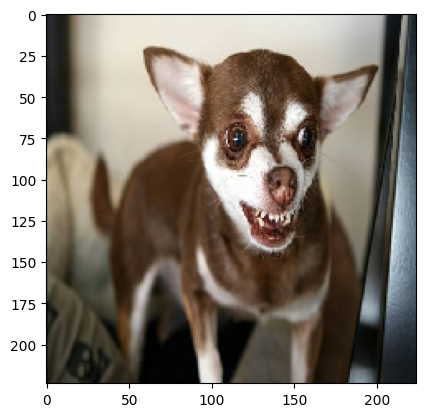

In [9]:
#Carregando o modelo do ResNet-50 pré-treinado com os pesos do ImageNet
model = resnet50.ResNet50(weights='imagenet')
#Padronizando os dados de entrada
X = resnet50.preprocess_input(image_np.copy())
#Fazendo a previsão
y = model.predict(X)
predicted_labels = decode_predictions(y)
print('predictions = ', predicted_labels) #Mostrando as previsões em formato de texto
#Mostrando a imagem
plt.imshow(np.uint8(image_np[0]))
plt.show()

Mais de 90% na previsão de um Chihuahua, isso mostra o porque o erro dele no ImageNet foi tão baixo.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
predictions =  [[('n03642806', 'laptop', np.float32(0.32270357)), ('n03793489', 'mouse', np.float32(0.11390183)), ('n03782006', 'monitor', np.float32(0.09526434)), ('n02124075', 'Egyptian_cat', np.float32(0.06744574)), ('n03179701', 'desk', np.float32(0.059184957))]]


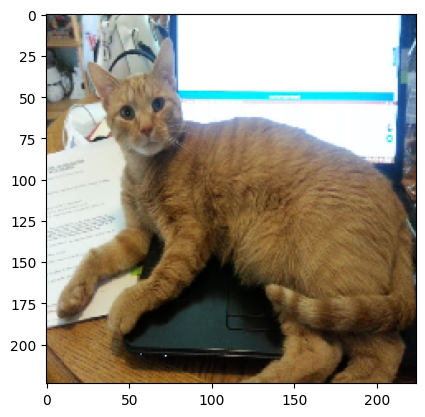

In [13]:
#Carregando o modelo do ResNet-50 pré-treinado com os pesos do ImageNet
model = resnet50.ResNet50(weights='imagenet')
#Padronizando os dados de entrada
X = resnet50.preprocess_input(image_np.copy())
#Fazendo a previsão
y = model.predict(X)
predicted_labels = decode_predictions(y)
print('predictions = ', predicted_labels) #Mostrando as previsões em formato de texto
#Mostrando a imagem
plt.imshow(np.uint8(image_np[0]))
plt.show()

Nesse caso ele identificou mais o laptop do que o gato, porém, ainda assim, tinha gato em suas previsões.